<a href="https://colab.research.google.com/github/Yahir-7/Data_Center_GeoPandas/blob/main/Unemployed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

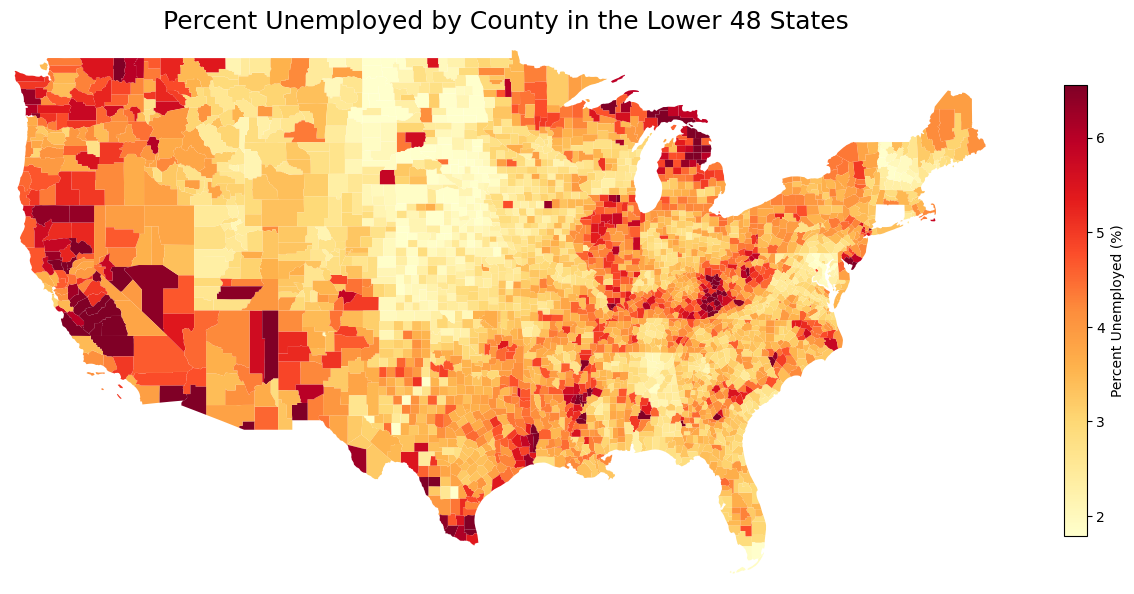

In [2]:
# Run once
# !pip install geopandas pandas matplotlib numpy

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

# Read data in excel file using pandas

file = "/content/2025 County Health Rankings Data - v4.xlsx"

chr_data = pd.read_excel(
    file,
    sheet_name="Select Measure Data",
    header=1
)

# Keep the important information

employment_df = chr_data[
    [
        "FIPS",
        "State",
        "County",
        "# Unemployed",
        "% Unemployed"
    ]
].copy()

# Keep only county rows
employment_df = employment_df[employment_df["County"].notna()].copy()

# Some values are missing -> removes all values that missing
employment_df = employment_df[employment_df["% Unemployed"].notna()].copy()

# Make FIPS match county shapefile GEOID -> converts int to string and makes sure it is 5 in length
employment_df["FIPS"] = (
    employment_df["FIPS"]
    .astype(int)
    .astype(str)
    .str.zfill(5)
)
# Testing

# print(employment_df.head())
# print("Number of counties in spreadsheet:", len(employment_df))

# Load county shapefile from Census

counties = gpd.read_file(
    "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_county_20m.zip"
)

# Make sure coordinates are latitude/longitude

counties = counties.to_crs(epsg=4326)

# Merge unemployment data with county map

merged = counties.merge(
    employment_df,
    left_on="GEOID",
    right_on="FIPS",
    how="inner"
)

# print("Number of counties after merge:", len(merged))

# Keep only Lower 48 states
# Filters out only USA data using latitide/longitude

lower48 = merged.cx[-125:-66, 24:50].copy()

# Remove Alaska, Hawaii, and territories by state name too
remove_states = [
    "Alaska",
    "Hawaii",
    "Puerto Rico",
    "Guam",
    "American Samoa",
    "Northern Mariana Islands",
    "Virgin Islands"
]

lower48 = lower48[~lower48["State"].isin(remove_states)].copy()

# Plot map using unemployment rate

vmin = lower48["% Unemployed"].quantile(0.02)
vmax = lower48["% Unemployed"].quantile(0.98)

fig, ax = plt.subplots(figsize=(16, 9))

lower48.plot(
    column="% Unemployed",
    cmap="YlOrRd",
    legend=True,
    edgecolor="none",
    linewidth=0,
    vmin=vmin,
    vmax=vmax,
    ax=ax,
    legend_kwds={
        "label": "Percent Unemployed (%)",
        "shrink": 0.65
    }
)

ax.set_xlim(-125, -66)
ax.set_ylim(24, 50)

ax.set_title("Percent Unemployed by County in the Lower 48 States", fontsize=18)
ax.axis("off")

plt.show()